# 🎯 Projeto de 1 Fator — Domínio (4 datasets), ANOVA desbalanceada

Modelo: $y_{ij} = \mu + \alpha_j + e_{ij}$, com $\sum_j r_j\,\alpha_j = 0$ e
$N=\sum_j r_j$ (réplicas podem diferir por nível — **amostras de tamanhos
diferentes**).

- **Fator:** `dataset` (4 níveis) — AGNews, MovieReview (geral); DBLP, Books (técnico).
- **Resposta** $y_{ij}$: **F1-macro** (e **Acurácia**) do **consenso por voto
  majoritário** da réplica *j* do dataset *i* (reutiliza `ConsensusCalculator`).
- **Réplicas:** pastas com *timestamp* (após "… - 3 modelos"); até 5 por nível.

**Tabela ANOVA** (Jain): SSY, SS0, SST, **SSA = Σ rⱼ αⱼ²**, SSE, g.l., MS,
**F = MSA/MSE** vs **F_tabela**, %Var. **ICs dos efeitos** com:
$Var(\hat\mu)=s_e^2/N$, $Var(\hat\alpha_j)=s_e^2(N-r_j)/(N r_j)$,
$Var(\hat\mu+\hat\alpha_j)=s_e^2/r_j$, contraste $Var=s_e^2\sum h_j^2/r_j$;
**g.l. do erro = N − a**.

> ⚠️ Roda com os dados atuais (desbalanceado) e escala automaticamente. Hoje:
> movie/books = 5; agnews/dblp em coleta.


## 1) Setup e configuração

In [1]:
import os, sys, re, glob, json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import accuracy_score, f1_score
from loguru import logger

ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

logger.remove()
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"] = 110

MODELS = ["deepseek-r1-8b", "qwen3-8b", "llama3.1-8b"]
CONS_COLS = [f"{m}_consensus" for m in MODELS]
DATASETS = ["agnews", "movie_review", "dblp", "books"]
DOMINIO = {"agnews": "geral", "movie_review": "geral", "dblp": "técnico", "books": "técnico"}
N_REPS = 5
INVALID = -1
RESULTS_DIR = ROOT / "data" / "results"
FIG_DIR = ROOT / "src" / "notebooks" / "mq" / "figuras"
print("Raiz do projeto:", ROOT)

Raiz do projeto: C:\Users\gabri\Documents\GitHub\llm-annotation


## 2) Selecionar as réplicas (pastas com *timestamp*)

Pastas cujo nome começa com `YYYY-MM-DD_HH-MM-SS` (após "… - 3 modelos"), até 5.

In [2]:
TS = re.compile(r"^\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}")

def replication_folders(dataset, n=N_REPS):
    fs = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
        and TS.match(os.path.basename(d.rstrip(os.sep)))
    )
    return fs[-n:]

REPLICATION_FOLDERS = {ds: replication_folders(ds) for ds in DATASETS}
incompletos = []
for ds in DATASETS:
    fs = REPLICATION_FOLDERS[ds]
    if len(fs) != N_REPS:
        incompletos.append((ds, len(fs)))
    print(f"  {ds:13s} ({DOMINIO[ds]:7s}): r_j = {len(fs)}")
    for f in fs:
        print(f"        - {os.path.basename(os.path.normpath(f))}")
if incompletos:
    print(f"\n⚠️ DESENHO DESBALANCEADO/INCOMPLETO: {incompletos} — a ANOVA já suporta "
          "r_j diferentes; reexecute quando a coleta avançar.")

  agnews        (geral  ): r_j = 2
        - 2026-04-09_13-20-16
        - 2026-06-25_22-01-14
  movie_review  (geral  ): r_j = 5
        - 2026-04-09_13-17-23
        - 2026-05-17_14-44-16
        - 2026-05-17_21-51-31
        - 2026-05-18_06-14-02
        - 2026-05-18_22-29-27
  dblp          (técnico): r_j = 4
        - 2026-04-09_14-05-21
        - 2026-06-21_03-43-57
        - 2026-06-23_17-40-12
        - 2026-06-27_16-06-33
  books         (técnico): r_j = 5
        - 2026-04-09_13-21-37
        - 2026-05-20_21-44-17
        - 2026-05-23_00-20-50
        - 2026-05-24_20-47-50
        - 2026-05-26_18-26-27

⚠️ DESENHO DESBALANCEADO/INCOMPLETO: [('agnews', 2), ('dblp', 4)] — a ANOVA já suporta r_j diferentes; reexecute quando a coleta avançar.


## 3) Resposta por réplica — F1/Acurácia do consenso (voto majoritário)

In [3]:
def get_categories(df):
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)

def consensus_quality(df_raw, categories, output_dir):
    calc = ConsensusCalculator(consensus_threshold=0.8, default_strategy="majority_vote")
    ev = ConsensusEvaluator(categories=categories, calculator=calc, output_dir=output_dir)
    sub = df_raw[["text_id", "text", "ground_truth"] + CONS_COLS].copy()
    dfc = ev.compute_consensus(sub)
    dfc = dfc[dfc["ground_truth"] != INVALID]
    cov = dfc[dfc["resolved_annotation"].notna()
              & (dfc["resolved_annotation"] != INVALID)
              & (~dfc["is_problematic"])]
    yt = cov["ground_truth"].astype(int); yp = cov["resolved_annotation"].astype(int)
    return {"f1_macro": f1_score(yt, yp, average="macro", zero_division=0),
            "accuracy": accuracy_score(yt, yp),
            "coverage": len(cov) / len(dfc) if len(dfc) else 0.0, "n_cob": len(cov)}

## 4) Tabela do experimento (uma linha por réplica)

In [4]:
rows = []
for ds in DATASETS:
    for rep_idx, folder in enumerate(REPLICATION_FOLDERS[ds], 1):
        df_raw = pd.read_csv(os.path.join(folder, "annotations.csv"))
        q = consensus_quality(df_raw, get_categories(df_raw), folder)
        rows.append({"dataset": ds, "dominio": DOMINIO[ds], "replica": rep_idx,
                     "pasta": os.path.basename(os.path.normpath(folder)), **q})

df1 = pd.DataFrame(rows)
print("Observações N =", len(df1), "| r_j por nível:")
print(df1.groupby("dataset").size().reindex(DATASETS))
df1

Observações N = 16 | r_j por nível:
dataset
agnews          2
movie_review    5
dblp            4
books           5
dtype: int64


,dataset,dominio,replica,pasta,f1_macro,accuracy,coverage,n_cob
0,agnews,geral,1,2026-04-09_13-20-16,0.8652,0.8676,0.9977,127309
1,agnews,geral,2,2026-06-25_22-01-14,0.8670,0.8692,0.9970,127223
2,movie_review,geral,1,2026-04-09_13-17-23,0.9135,0.9135,0.9992,10653
3,movie_review,geral,2,2026-05-17_14-44-16,0.9131,0.9131,0.9988,10649
4,movie_review,geral,3,2026-05-17_21-51-31,0.9124,0.9124,0.9989,10650
5,movie_review,geral,4,2026-05-18_06-14-02,0.9142,0.9142,0.9987,10648
6,movie_review,geral,5,2026-05-18_22-29-27,0.9126,0.9126,0.9994,10656
7,dblp,técnico,1,2026-04-09_14-05-21,0.6202,0.6456,0.9786,37238
8,dblp,técnico,2,2026-06-21_03-43-57,0.6204,0.6480,0.9721,36993
9,dblp,técnico,3,2026-06-23_17-40-12,0.6191,0.6479,0.9712,36958


## 5) Função — ANOVA de 1 fator (desbalanceada) + IC dos efeitos

Segue exatamente a tabela do Jain (amostras de tamanhos diferentes):

- $\bar{y}_{..}=\hat\mu$ ; $\hat\alpha_j=\bar{y}_{.j}-\hat\mu$ (com $\sum_j r_j\alpha_j=0$)
- $SSY=\sum y_{ij}^2$ ; $SS0=N\hat\mu^2$ ; $SST=SSY-SS0$
- $SSA=\sum_j r_j\hat\alpha_j^2$ ; $SSE=SST-SSA$
- $MSA=SSA/(a-1)$ ; $MSE=SSE/(N-a)$ ; $s_e=\sqrt{MSE}$ ; $F=MSA/MSE$
- ICs: $\hat\mu\pm t\sqrt{s_e^2/N}$ ; $\hat\alpha_j\pm t\sqrt{s_e^2(N-r_j)/(N r_j)}$ ;
  $\hat\mu+\hat\alpha_j\pm t\sqrt{s_e^2/r_j}$ ; contraste $\pm t\,s_e\sqrt{\sum h_j^2/r_j}$
  (g.l. = N−a).

In [5]:
def one_way_anova(data, response, factor="dataset", alpha=0.05):
    grp = data.groupby(factor, sort=False)[response]
    levels = list(grp.groups.keys())
    rj = grp.count().to_numpy(dtype=float)        # réplicas por nível
    ybar_j = grp.mean().to_numpy()                # média por nível
    y = data[response].to_numpy(dtype=float)
    N, a = len(y), len(levels)
    mu = y.mean()                                 # ȳ.. (média ponderada = geral)
    alpha_j = ybar_j - mu                         # efeitos

    SSY = float((y ** 2).sum())
    SS0 = float(N * mu ** 2)
    SST = SSY - SS0
    SSA = float(np.sum(rj * alpha_j ** 2))
    SSE = SST - SSA
    dfA, dfE = a - 1, N - a
    MSA = SSA / dfA if dfA > 0 else np.nan
    MSE = SSE / dfE if dfE > 0 else np.nan
    se = np.sqrt(MSE) if (MSE is not None and MSE >= 0) else np.nan
    F = MSA / MSE if (MSE and MSE > 0) else np.nan
    F_tab = stats.f.ppf(1 - alpha, dfA, dfE) if dfE > 0 else np.nan
    pval = float(stats.f.sf(F, dfA, dfE)) if np.isfinite(F) else np.nan
    t = stats.t.ppf(1 - alpha / 2, dfE) if dfE > 0 else np.nan

    anova = pd.DataFrame([
        {"componente": "Y",            "SS": SSY, "g.l.": N,     "MS": np.nan, "% Var": np.nan},
        {"componente": "ȳ.. (média)",  "SS": SS0, "g.l.": 1,     "MS": np.nan, "% Var": np.nan},
        {"componente": "y − ȳ.. (SST)","SS": SST, "g.l.": N - 1, "MS": np.nan, "% Var": 100.0},
        {"componente": "A — Domínio (SSA)", "SS": SSA, "g.l.": dfA, "MS": MSA,
         "% Var": 100 * SSA / SST if SST > 0 else np.nan},
        {"componente": "Erros (SSE)",  "SS": SSE, "g.l.": dfE, "MS": MSE,
         "% Var": 100 * SSE / SST if SST > 0 else np.nan},
    ])

    var_alpha = se ** 2 * (N - rj) / (N * rj)     # Var(α_j)
    var_mean = se ** 2 / rj                        # Var(μ+α_j)
    niveis = pd.DataFrame({
        factor: levels, "r_j": rj.astype(int), "media (ȳ.j)": ybar_j,
        "efeito α_j": alpha_j,
        "α_j IC_low": alpha_j - t * np.sqrt(var_alpha),
        "α_j IC_high": alpha_j + t * np.sqrt(var_alpha),
        "média IC_low": ybar_j - t * np.sqrt(var_mean),
        "média IC_high": ybar_j + t * np.sqrt(var_mean),
        "α_j significativo (0∉IC)": (alpha_j - t * np.sqrt(var_alpha) > 0) | (alpha_j + t * np.sqrt(var_alpha) < 0),
    })

    pares = []
    for i, j in combinations(range(a), 2):
        diff = ybar_j[i] - ybar_j[j]
        h = t * se * np.sqrt(1 / rj[i] + 1 / rj[j])
        pares.append({"par": f"{levels[i]} − {levels[j]}", "diferença": diff,
                      "IC_low": diff - h, "IC_high": diff + h,
                      "difere (0∉IC)": not (diff - h <= 0 <= diff + h)})
    pairwise = pd.DataFrame(pares)

    mu_ci = (mu - t * np.sqrt(se ** 2 / N), mu + t * np.sqrt(se ** 2 / N)) if dfE > 0 else (np.nan, np.nan)
    return {"response": response, "anova": anova, "niveis": niveis, "pairwise": pairwise,
            "mu": mu, "mu_IC": mu_ci, "F": F, "F_tab": F_tab, "p_value": pval,
            "se": se, "MSE": MSE, "dfA": dfA, "dfE": dfE, "N": N, "a": a,
            "pct_fator": 100 * SSA / SST if SST > 0 else np.nan,
            "soma_rj_alpha": float(np.sum(rj * alpha_j))}   # ~0 (checagem)

## 6) Premissas — **verificadas antes da análise**

Resíduos $e_{ij}=y_{ij}-\bar{y}_{.j}$: normalidade (Shapiro + QQ + histograma),
homoscedasticidade (Levene/Bartlett entre níveis), independência (Durbin-Watson).
Testes de variância/normalidade usam níveis com **≥ 2 réplicas**.

Premissas (resíduos) — F1 e Acurácia:


,resposta,niveis_>=2rep,Shapiro_W,Shapiro_p,normal_ok,Levene_p,Bartlett_p,homoced_ok,Durbin_Watson
0,f1_macro,4,0.9426,0.3816,True,0.2380,0.5309,True,2.6490
1,accuracy,4,0.9507,0.5005,True,0.2948,0.2681,True,2.7218


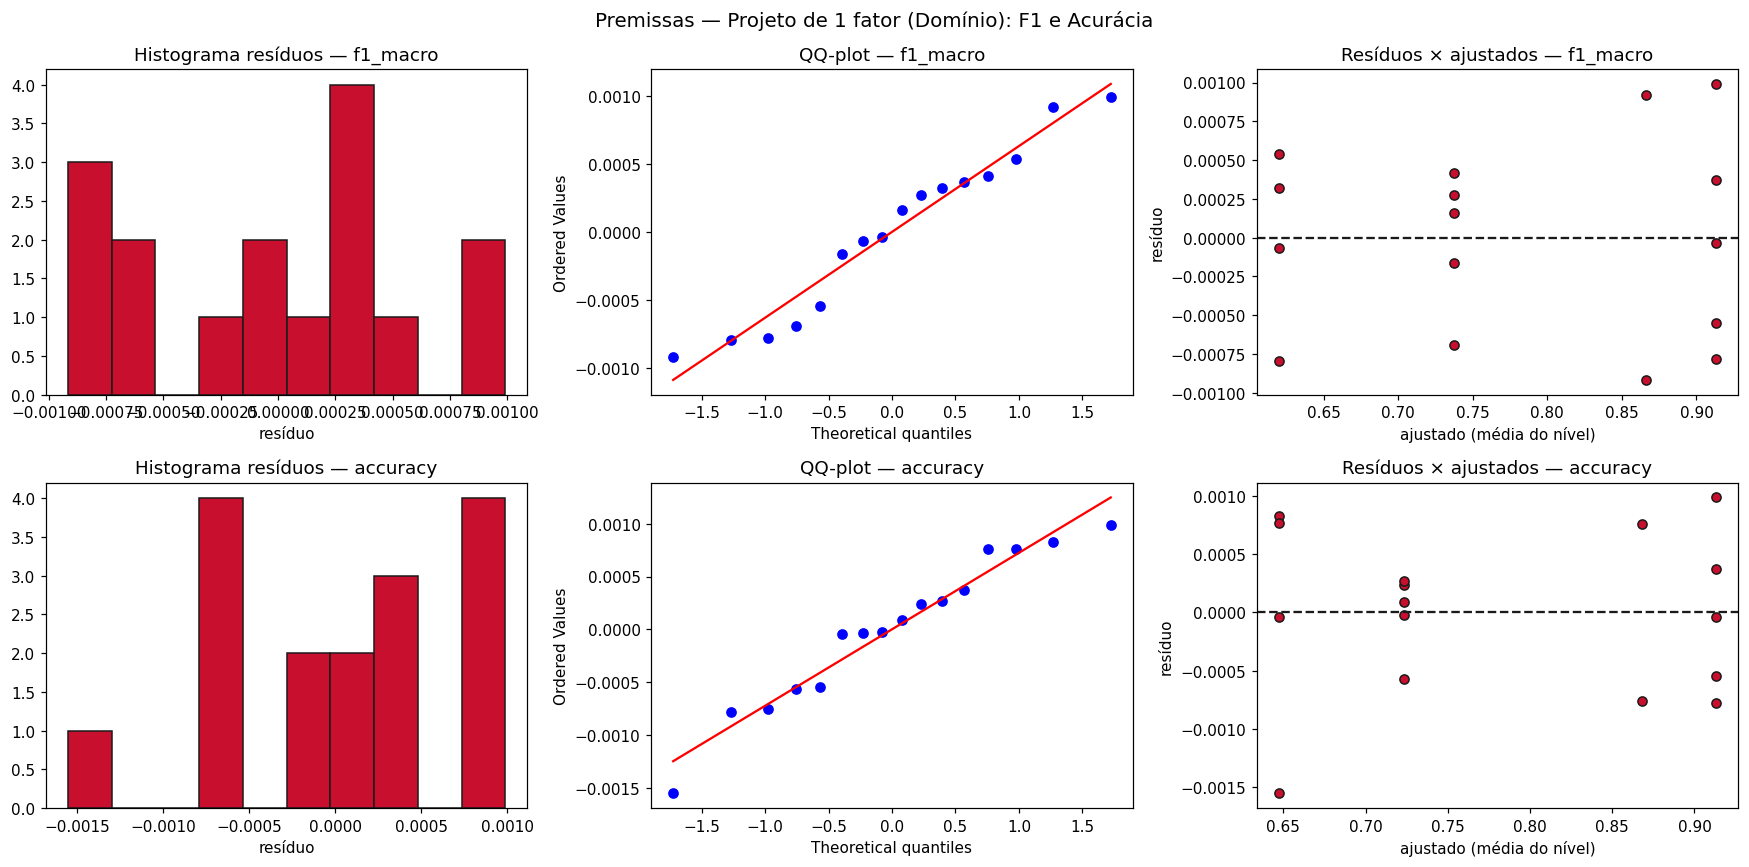

Reteste após logit (se premissas violadas):


,resposta,niveis_>=2rep,Shapiro_W,Shapiro_p,normal_ok,Levene_p,Bartlett_p,homoced_ok,Durbin_Watson
0,f1_logit,4,0.9669,0.7868,True,0.0306,0.0387,False,2.9120
1,acc_logit,4,0.9640,0.7338,True,0.0807,0.0600,True,2.9361


In [6]:
def _residuos(data, response, factor="dataset"):
    d = data.copy()
    d["_fit"] = d.groupby(factor)[response].transform("mean")
    d["_res"] = d[response] - d["_fit"]
    return d

def testar_premissas(data, response, factor="dataset"):
    d = _residuos(data, response, factor)
    g2 = [g for _, g in d.groupby(factor) if len(g) >= 2]
    out = {"resposta": response, "niveis_>=2rep": len(g2)}
    if not g2:
        out["aviso"] = "sem níveis com ≥2 réplicas"; return out
    resid = np.concatenate([g["_res"].to_numpy() for g in g2])
    if len(resid) >= 3:
        W, p = stats.shapiro(resid); out.update({"Shapiro_W": W, "Shapiro_p": p, "normal_ok": p >= 0.05})
    if len(g2) >= 2:
        gg = [g[response].to_numpy() for g in g2]
        out["Levene_p"] = stats.levene(*gg, center="median")[1]
        out["Bartlett_p"] = stats.bartlett(*gg)[1]
        out["homoced_ok"] = out["Levene_p"] >= 0.05
    out["Durbin_Watson"] = float(np.sum(np.diff(resid) ** 2) / np.sum(resid ** 2))
    return out

print("Premissas (resíduos) — F1 e Acurácia:")
display(pd.DataFrame([testar_premissas(df1, "f1_macro"), testar_premissas(df1, "accuracy")]))

def plot_residuos(data, response, axes, factor="dataset"):
    d = _residuos(data, response, factor)
    d = pd.concat([g for _, g in d.groupby(factor) if len(g) >= 2]) \
        if any(len(g) >= 2 for _, g in d.groupby(factor)) else d
    resid = d["_res"].to_numpy(); fit = d["_fit"].to_numpy()
    axes[0].hist(resid, bins=10, color="#C8102E", edgecolor="#1A1A1A")
    axes[0].set_title(f"Histograma resíduos — {response}"); axes[0].set_xlabel("resíduo")
    if len(resid) >= 3:
        stats.probplot(resid, dist="norm", plot=axes[1])
    axes[1].set_title(f"QQ-plot — {response}")
    axes[2].scatter(fit, resid, color="#C8102E", edgecolor="#1A1A1A")
    axes[2].axhline(0, color="#1A1A1A", ls="--")
    axes[2].set_xlabel("ajustado (média do nível)"); axes[2].set_ylabel("resíduo")
    axes[2].set_title(f"Resíduos × ajustados — {response}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_residuos(df1, "f1_macro", axes[0]); plot_residuos(df1, "accuracy", axes[1])
fig.suptitle("Premissas — Projeto de 1 fator (Domínio): F1 e Acurácia", fontsize=13)
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "_prem_um_fator.png", bbox_inches="tight")
plt.show()

def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps); return np.log(p / (1 - p))
_dl = df1.copy(); _dl["f1_logit"] = _logit(_dl["f1_macro"]); _dl["acc_logit"] = _logit(_dl["accuracy"])
print("Reteste após logit (se premissas violadas):")
display(pd.DataFrame([testar_premissas(_dl, "f1_logit"), testar_premissas(_dl, "acc_logit")]))

## 7) ANOVA de 1 fator — Resposta = **F1 Macro**

In [7]:
res_f1 = one_way_anova(df1, "f1_macro")
print(f"F_computado = {res_f1['F']:.3f}   F_tabela(5%; {res_f1['dfA']},{res_f1['dfE']}) = {res_f1['F_tab']:.3f}"
      f"   → {'REJEITA H0 (domínio importa)' if res_f1['F'] > res_f1['F_tab'] else 'não rejeita H0'}")
print(f"p = {res_f1['p_value']:.3g} | domínio explica {res_f1['pct_fator']:.1f}% | "
      f"s_e = {res_f1['se']:.4f} | Σ r_j·α_j = {res_f1['soma_rj_alpha']:.2e} (~0)")
print("\nTabela ANOVA (F1):")
display(res_f1["anova"])
print("Efeitos (α_j) e médias por nível com IC 95% (F1):")
display(res_f1["niveis"])
print("Comparações entre pares (IC 95% da diferença):")
display(res_f1["pairwise"])
print(f"Média geral μ = {res_f1['mu']:.4f}  IC95% [{res_f1['mu_IC'][0]:.4f}, {res_f1['mu_IC'][1]:.4f}]")

F_computado = 156050.904   F_tabela(5%; 3,12) = 3.490   → REJEITA H0 (domínio importa)
p = 8.32e-28 | domínio explica 100.0% | s_e = 0.0007 | Σ r_j·α_j = -5.55e-16 (~0)

Tabela ANOVA (F1):


,componente,SS,g.l.,MS,% Var
0,Y,9.9247,16,NaN,NaN
1,ȳ.. (média),9.7095,1,NaN,NaN
2,y − ȳ.. (SST),0.2152,15,NaN,100.0000
3,A — Domínio (SSA),0.2152,3,0.0717,99.9974
4,Erros (SSE),0.0000,12,0.0000,0.0026


Efeitos (α_j) e médias por nível com IC 95% (F1):


,dataset,r_j,media (ȳ.j),efeito α_j,α_j IC_low,α_j IC_high,média IC_low,média IC_high,α_j significativo (0∉IC)
0,agnews,2,0.8661,0.0871,0.0861,0.0881,0.8651,0.8671,True
1,movie_review,5,0.9132,0.1342,0.1336,0.1347,0.9125,0.9138,True
2,dblp,4,0.6199,-0.1591,-0.1598,-0.1585,0.6191,0.6206,True
3,books,5,0.7373,-0.0417,-0.0422,-0.0411,0.7367,0.7380,True


Comparações entre pares (IC 95% da diferença):


,par,diferença,IC_low,IC_high,difere (0∉IC)
0,agnews − movie_review,-0.0471,-0.0483,-0.0458,True
1,agnews − dblp,0.2462,0.2450,0.2475,True
2,agnews − books,0.1288,0.1275,0.1300,True
3,movie_review − dblp,0.2933,0.2923,0.2943,True
4,movie_review − books,0.1758,0.1749,0.1768,True
5,dblp − books,-0.1175,-0.1185,-0.1165,True


Média geral μ = 0.7790  IC95% [0.7786, 0.7794]


## 8) ANOVA de 1 fator — Resposta = **Acurácia**

In [8]:
res_acc = one_way_anova(df1, "accuracy")
print(f"F_computado = {res_acc['F']:.3f}   F_tabela(5%; {res_acc['dfA']},{res_acc['dfE']}) = {res_acc['F_tab']:.3f}"
      f"   → {'REJEITA H0' if res_acc['F'] > res_acc['F_tab'] else 'não rejeita H0'}")
print(f"p = {res_acc['p_value']:.3g} | domínio explica {res_acc['pct_fator']:.1f}%")
display(res_acc["anova"]); display(res_acc["niveis"]); display(res_acc["pairwise"])

F_computado = 104345.650   F_tabela(5%; 3,12) = 3.490   → REJEITA H0
p = 9.3e-27 | domínio explica 100.0%


,componente,SS,g.l.,MS,% Var
0,Y,9.9704,16,NaN,NaN
1,ȳ.. (média),9.7796,1,NaN,NaN
2,y − ȳ.. (SST),0.1908,15,NaN,100.0000
3,A — Domínio (SSA),0.1908,3,0.0636,99.9962
4,Erros (SSE),0.0000,12,0.0000,0.0038


,dataset,r_j,media (ȳ.j),efeito α_j,α_j IC_low,α_j IC_high,média IC_low,média IC_high,α_j significativo (0∉IC)
0,agnews,2,0.8684,0.0866,0.0855,0.0877,0.8672,0.8696,True
1,movie_review,5,0.9132,0.1314,0.1307,0.1320,0.9124,0.9139,True
2,dblp,4,0.6471,-0.1347,-0.1354,-0.1339,0.6463,0.6480,True
3,books,5,0.7236,-0.0583,-0.0589,-0.0576,0.7228,0.7243,True


,par,diferença,IC_low,IC_high,difere (0∉IC)
0,agnews − movie_review,-0.0448,-0.0462,-0.0434,True
1,agnews − dblp,0.2213,0.2198,0.2227,True
2,agnews − books,0.1448,0.1434,0.1463,True
3,movie_review − dblp,0.2660,0.2649,0.2672,True
4,movie_review − books,0.1896,0.1885,0.1907,True
5,dblp − books,-0.0764,-0.0776,-0.0753,True


## 9) Gráficos

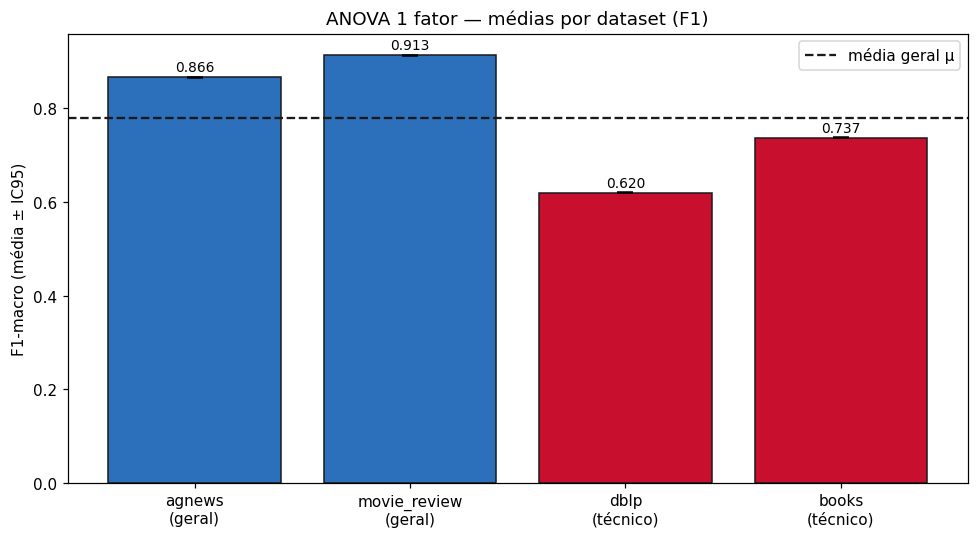

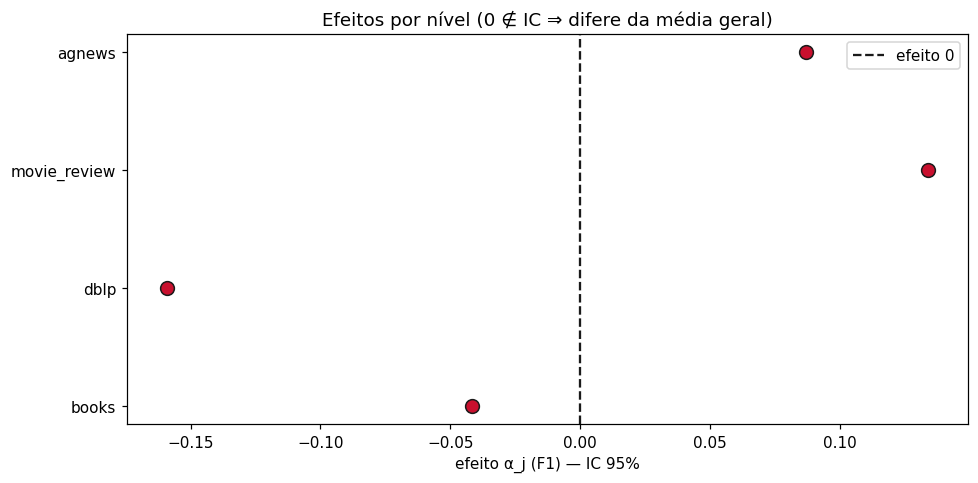

In [9]:
DOM_COR = {"geral": "#2c6fbb", "técnico": "#C8102E"}

# médias por dataset (μ+α_j) com IC 95%
niv = res_f1["niveis"]
fig, ax = plt.subplots(figsize=(9, 5))
xs = np.arange(len(niv))
yerr = [niv["media (ȳ.j)"] - niv["média IC_low"], niv["média IC_high"] - niv["media (ȳ.j)"]]
ax.bar(xs, niv["media (ȳ.j)"], yerr=yerr, capsize=5,
       color=[DOM_COR[DOMINIO[d]] for d in niv["dataset"]], edgecolor="#1A1A1A")
ax.axhline(res_f1["mu"], color="#1A1A1A", ls="--", label="média geral μ")
for x, m in zip(xs, niv["media (ȳ.j)"]):
    ax.annotate(f"{m:.3f}", (x, m), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels([f"{d}\n({DOMINIO[d]})" for d in niv["dataset"]])
ax.set_ylabel("F1-macro (média ± IC95)"); ax.set_title("ANOVA 1 fator — médias por dataset (F1)")
ax.legend(); plt.tight_layout(); plt.show()

# efeitos α_j com IC 95% (forest)
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(niv))[::-1]
for yi, (_, r) in zip(y, niv.iterrows()):
    sig = r["α_j significativo (0∉IC)"]
    cor = "#C8102E" if sig else "#9A9A9A"
    ax.plot([r["α_j IC_low"], r["α_j IC_high"]], [yi, yi], "-", color=cor, lw=3)
    ax.plot(r["efeito α_j"], yi, "o", color=cor, ms=9, markeredgecolor="#1A1A1A")
ax.axvline(0, color="#1A1A1A", ls="--", label="efeito 0")
ax.set_yticks(y); ax.set_yticklabels(niv["dataset"])
ax.set_xlabel("efeito α_j (F1) — IC 95%"); ax.set_title("Efeitos por nível (0 ∉ IC ⇒ difere da média geral)")
ax.legend(); plt.tight_layout(); plt.show()

## 10) Resumo / interpretação

- **F_computado vs F_tabela** (§7/§8): se F_comp > F_tab (ou p<0,05) → o **domínio
  afeta** significativamente a qualidade; **% Var** mostra quanto ele explica.
- **Efeitos α_j**: cada dataset acima/abaixo da média geral; **0 ∉ IC** ⇒ aquele
  nível difere significativamente da média.
- **Comparações por par**: IC da diferença sem o 0 ⇒ os dois datasets diferem.
- **Desbalanceado**: as variâncias dos ICs usam r_j por nível (Jain); enquanto
  agnews/dblp tiverem poucas réplicas, leia com cautela e reexecute após a coleta.

## 11) Exportar análise (.json) — `data/results/mq/um_fator_dominio`

In [10]:
EXPORT_DIR = ROOT / "data" / "results" / "mq" / "um_fator_dominio"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def _j(o):
    if isinstance(o, pd.DataFrame): return o.to_dict(orient="records")
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    if isinstance(o, dict): return {k: _j(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_j(v) for v in o]
    return o

reps = {ds: int((df1["dataset"] == ds).sum()) for ds in DATASETS}
def _resumo(res):
    return {"anova": _j(res["anova"]), "niveis": _j(res["niveis"]), "pairwise": _j(res["pairwise"]),
            "F": None if not np.isfinite(res["F"]) else float(res["F"]),
            "F_tab": None if not np.isfinite(res["F_tab"]) else float(res["F_tab"]),
            "p_value": res["p_value"], "pct_fator": res["pct_fator"],
            "mu": res["mu"], "mu_IC": list(res["mu_IC"])}

payload = {
    "design": "1 fator (domínio) — ANOVA desbalanceada (r_j por nível)",
    "niveis": DOMINIO, "reps_por_dataset": reps, "N": int(len(df1)),
    "completo": all(v == N_REPS for v in reps.values()),
    "premissas": {"f1_macro": _j(testar_premissas(df1, "f1_macro")),
                  "accuracy": _j(testar_premissas(df1, "accuracy"))},
    "observacoes": _j(df1.drop(columns=["pasta"])),
    "anova": {"f1_macro": _resumo(res_f1), "accuracy": _resumo(res_acc)},
}
with open(EXPORT_DIR / "analise_um_fator_dominio.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
print("✓ Salvo em:", EXPORT_DIR, "| completo:", payload["completo"])

✓ Salvo em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\um_fator_dominio | completo: False
